In [1]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib
from matplotlib import animation

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')
from python.polygon_based_correction import *
from python.animation import *
from eval.eval import *
from python.dataset_conversion import *
from python.misprediction_classifier import *
from autoencoder.src.data_loader import *

sleap.versions()
sleap.system_summary()

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [2]:
dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_1m_w_scores.slp'
dataset = sleap.load_file(dataset_path)
print(dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)


In [4]:
multi_4k_points_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_predicted_points_with_score.npy'
multi_4k_points = np.load(multi_4k_points_path)
print(multi_4k_points.shape)
start_idx = 150 * 60 * 60
end_idx = 150 * 60 * 61
multi_pts_clip = multi_4k_points[start_idx:end_idx]
print(multi_pts_clip.shape)

(3240000, 17, 3)
(9000, 17, 3)


In [5]:
a1_pts = multi_pts_clip[:, :, :2]
a1_scores = multi_pts_clip[:, :, 2]

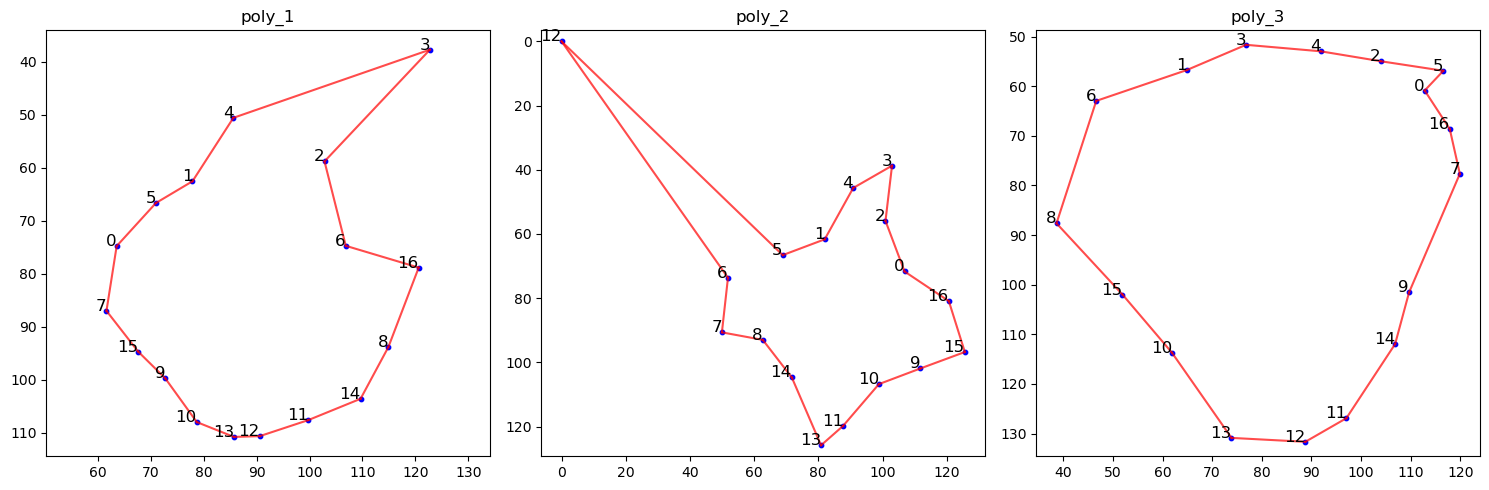


Total edge lengths:
poly_1: 231.676
poly_2: 422.117
poly_3: 257.237


In [15]:
frame_indices = [19, 32, 51]
plot_multiframe_polygons(a1_pts[frame_indices])

# ID mispredicted points

1. prediction score < 0.6 and nn to prev frame > 5 pixels
2. when nn distance < 5 pixels, keep the one with higher prediction score
3. check the angle between a point and its two nearest neighbor? and distance

use SVM (or anything that does classification) to classify? 

input features
- prediction score
- angle
- 2 nn distance (current frame)
- nn distance (prev frame) -> this needs the points to be contiguous in time

determine whether a point is "correct": nn dist to manulaay labeled frame < 5 pixels

## nn angle

In [34]:
def plot_nn_angle(frame_pts, poly_constructor=poly_4):
    poly_order = poly_constructor(frame_pts)
    frame_pts = frame_pts[poly_order]
    pt_cnt = frame_pts.shape[0]
    angles = calculate_polygon_angles(frame_pts)
    print(' '.join([f"{angle:.0f}" for angle in np.sort(angles)]))
    # print(f'min nn angle: {np.min(angles):.2f}, max nn angle: {np.max(angles):.2f}')
    plt.figure(figsize=(6, 4))
    plt.hist(angles, bins=pt_cnt)
    plt.xlabel('Nearest Neighbor Angle')
    plt.ylabel('Count')
    plt.show()

28 86 133 140 142 147 148 157 163 163 173 173 176 190 206 237 239


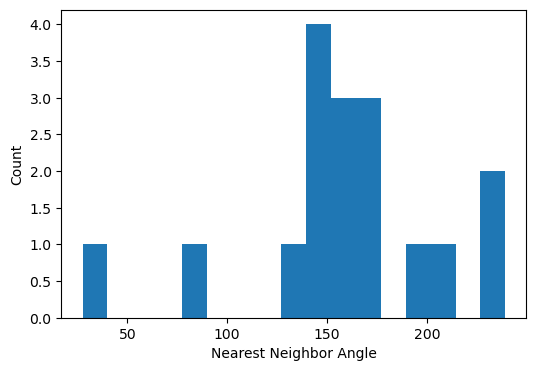

In [35]:
frame_idx = 19
plot_nn_angle(a1_pts[frame_idx])

11 53 72 93 94 141 149 172 180 194 207 209 216 220 221 222 245


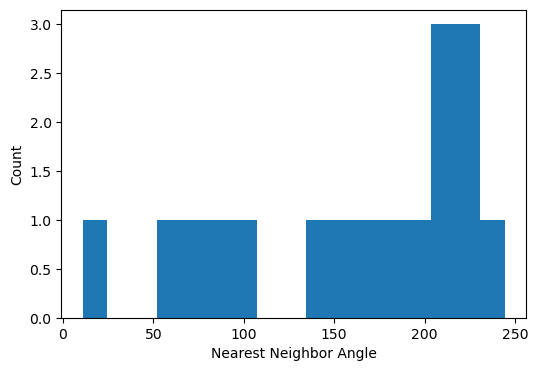

In [36]:
frame_idx = 32
plot_nn_angle(a1_pts[frame_idx])

55 119 127 128 144 147 152 153 160 162 176 181 182 184 185 188 256


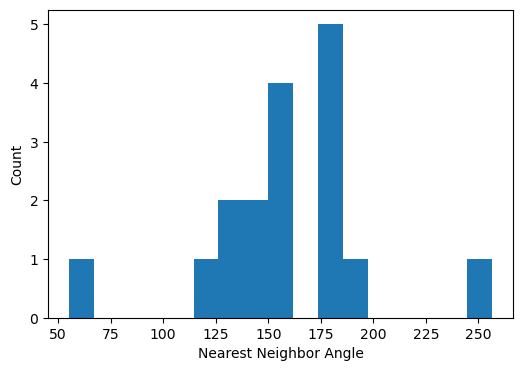

In [37]:
frame_idx = 51
plot_nn_angle(a1_pts[frame_idx])

## nn distance

In [16]:
def plot_nn_dist(frame_pts):
    pt_cnt = frame_pts.shape[0]
    nn_dists = []
    for i in range(pt_cnt):
        pt = frame_pts[i]
        dists = np.linalg.norm(frame_pts[np.arange(pt_cnt) != i] - pt, axis=1)
        nn_dists.append(np.min(dists))
    nn_dists = np.array(nn_dists)
    print(f'min nn dist: {np.min(nn_dists):.2f}, max nn dist: {np.max(nn_dists):.2f}')
    plt.hist(nn_dists, bins=pt_cnt)
    plt.xlabel('Nearest Neighbor Distance')
    plt.ylabel('Count')
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Force integer y-axis ticks
    plt.show()

min nn dist: 4.07, max nn dist: 21.01


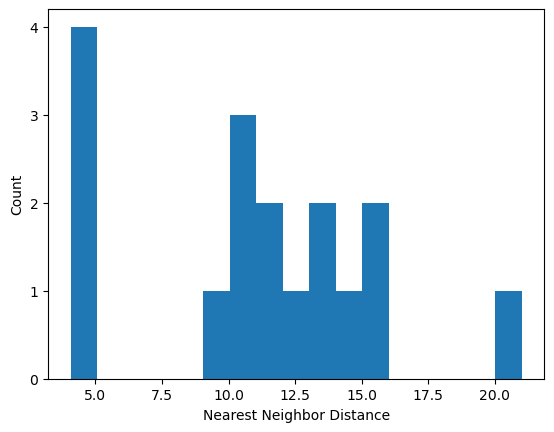

In [18]:
frame_idx = 50
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 5.47, max nn dist: 19.55


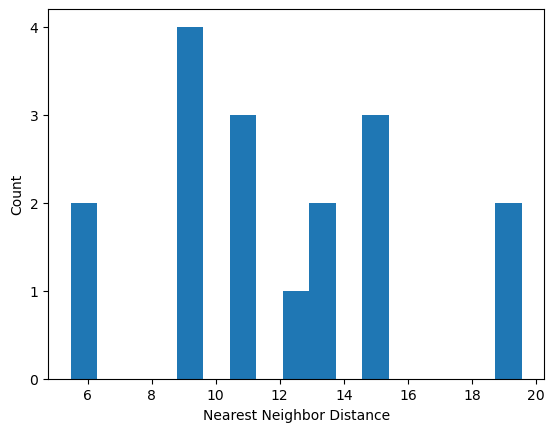

In [19]:
frame_idx = 51
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 8.58, max nn dist: 19.83


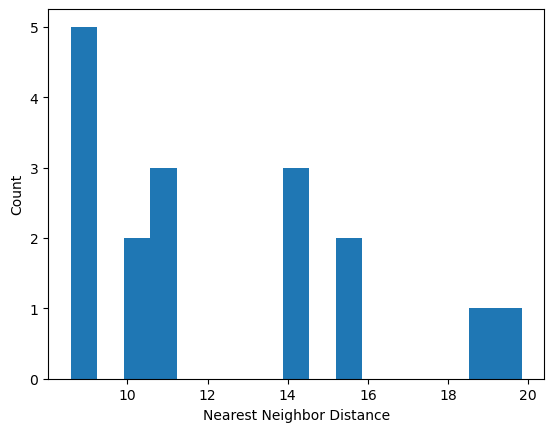

In [20]:
frame_idx = 53
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 4.73, max nn dist: 24.72


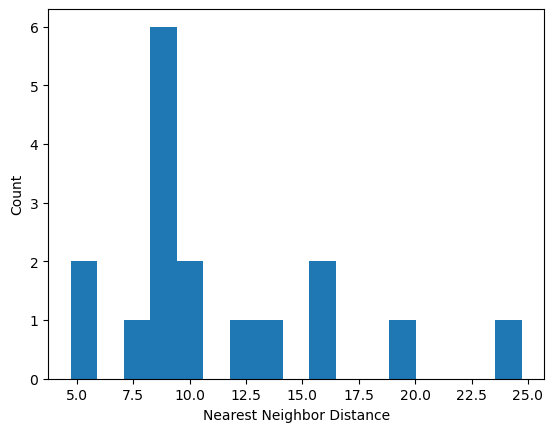

In [23]:
frame_idx = 56
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 5.21, max nn dist: 18.02


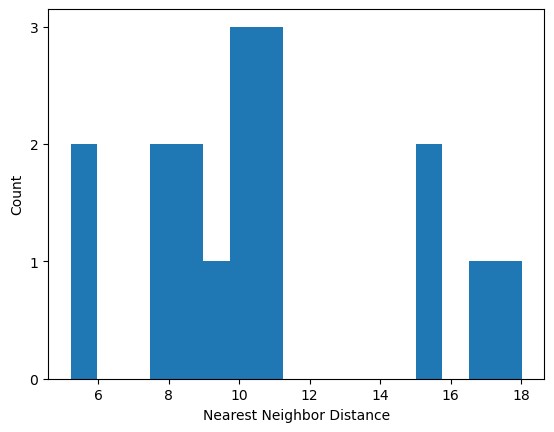

In [28]:
frame_idx = 61
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 4.93, max nn dist: 14.59


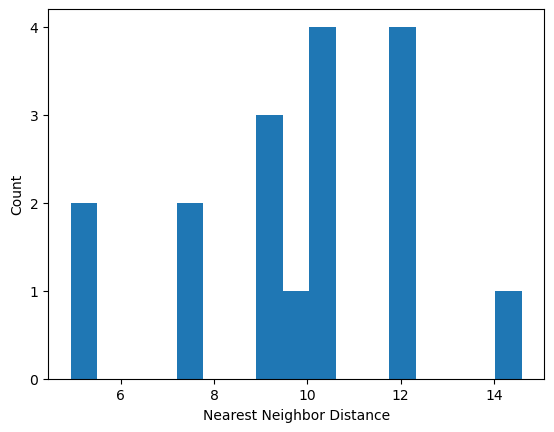

In [30]:
frame_idx = 66
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

## generate dataset for classification training

In [ ]:
# TODO: change prev frame nn finding method (?)

In [10]:
# cont_start_idx = 479850
cont_start_idx = 150 * 60 * 60
cont_end_idx = cont_start_idx + 3000
# cont_end_idx = cont_start_idx + 9000

In [6]:
new_4k_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/multifish_animal_1_v11.slp'
new_4k_dataset = sleap.load_file(new_4k_dataset_path)
print(new_4k_dataset)
new_4k_pts = get_all_untracked_points_from_lbfs(new_4k_dataset.labeled_frames, interpolate=False, reorder=False, use_labeled_only=True)
new_lbf_indices = np.array([lbf.frame_idx for lbf in new_4k_dataset.labeled_frames])
print(new_4k_pts.shape)
predicted_pts_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_predicted_points.npy'
predicted_pts = np.load(predicted_pts_path)[new_lbf_indices]
print(predicted_pts.shape)
gt_pts = new_4k_pts

pred_pts_score_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_predicted_points_with_score.npy'
pred_pts_score_all = np.load(pred_pts_score_path)
pred_pts_score = pred_pts_score_all[new_lbf_indices]
print(pred_pts_score.shape)

Labels(labeled_frames=4149, videos=1, skeletons=1, tracks=17)
all_untracked_points shape: (4149, 17, 2)


4149it [00:10, 393.80it/s]


Missing point count: 0
(4149, 17, 2)
(4149, 17, 2)
(4149, 17, 3)


In [4]:
sub_20s_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s.slp'
sub_20s_dataset = sleap.load_file(sub_20s_dataset_path)
print(sub_20s_dataset)


Labels(labeled_frames=0, videos=1, skeletons=0, tracks=0)


In [13]:
sub_20s_pts = pred_pts_score_all[cont_start_idx:cont_end_idx]
sub_20s_dataset_with_pts = multi_model_dataset_with_points(sub_20s_dataset, sub_20s_pts, 
                                                           with_score=False, add_track=False)
print(sub_20s_dataset_with_pts)

Tentacle count: 17
Track 0 is not assigned
Track 1 is not assigned
Track 2 is not assigned
Track 3 is not assigned
Track 4 is not assigned
Track 5 is not assigned
Track 6 is not assigned
Track 7 is not assigned
Track 8 is not assigned
Track 9 is not assigned
Track 10 is not assigned
Track 11 is not assigned
Track 12 is not assigned
Track 13 is not assigned
Track 14 is not assigned
Track 15 is not assigned
Track 16 is not assigned
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)


In [14]:
sub_20s_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores.slp'
sub_20s_dataset_with_pts.save(sub_20s_dataset_path)

In [116]:
cont_indices = (new_lbf_indices >= cont_start_idx) & (new_lbf_indices < cont_end_idx)
cont_gt_pts = gt_pts[cont_indices]
cont_pred_pts = predicted_pts[cont_indices]
cont_pred_pts_score = pred_pts_score[cont_indices]
print(cont_gt_pts.shape, cont_pred_pts.shape)

(2515, 17, 2) (2515, 17, 2)


In [117]:
def get_classification_dataset(pred_pts, gt_pts, dist_thres=3):
    """
    Args:
        pred_pts (np.array): (frame_cnt, pt_cnt, 3); predicted points in contiguous frames, 
                             where the last column is prediction score 
        gt_pts (np.array): (frame_cnt, pt_cnt, 2); labeled points in contiguous frames

    Returns:
        features: ((frame_cnt - 1) * pt_cnt, 4); 
                  4 features: prediction score, angle, 2 nn distance (current frame); nn distance (prev frame)
        labels: ((frame_cnt - 1) * pt_cnt, ); 1 = correct, 0 = incorrect 
    """
    pred_pts_score = pred_pts[1:, :, 2]
    pred_pts_angle = calculate_polygon_angles(pred_pts[1:, :, :2])
    pred_pts_2nn_dist = get_2nn_dist_multi_frame(pred_pts[1:, :, :2])
    pred_pts_prev_nn_dist = get_nn_dist_prev_frame(pred_pts[:, :, :2])
    features = np.stack([pred_pts_score, pred_pts_angle, pred_pts_2nn_dist, pred_pts_prev_nn_dist], axis=2)
    labels = get_labels(pred_pts[1:, :, :2], gt_pts[1:], dist_thres)
    nan_mask = np.isnan(features).any(axis=2)
    features = features[~nan_mask].reshape(-1, 4)
    labels = labels[~nan_mask]
    return features, labels, nan_mask

In [73]:
dist_thres = 6
labels = get_labels(cont_pred_pts, cont_gt_pts, dist_thres=dist_thres)
print(labels.shape)
print(f'{int(labels.sum())} out of {2515 * 17} ({labels.sum() / (2515 * 17):.2%}) points are correctly predicted with threshold {dist_thres}')

(2515, 17)
39216 out of 42755 (91.72%) points are correctly predicted


../eval/eval.py:309: RuntimeWarning: invalid value encountered in true_divide
  v2 /= np.linalg.norm(v2)
../eval/eval.py:308: RuntimeWarning: invalid value encountered in true_divide
  v1 /= np.linalg.norm(v1)


In [ ]:
cont_features, cont_labels, nan_mask = get_classification_dataset(cont_pred_pts_score, cont_gt_pts, dist_thres=3)

In [36]:
cont_labels.shape, cont_features.shape

((41910,), (41910, 4))

In [8]:
feature_cnt = 4
X = cont_features.reshape(-1, feature_cnt)
y = cont_labels.flatten()
print(X.shape, y.shape)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1)

(41910, 4) (41910,)


## train a classifier

### SVM

#### default params

In [43]:
# Train an SVM classifier
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

# Predict on test set
y_pred = svm_clf.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.937007874015748
              precision    recall  f1-score   support

         0.0       1.00      0.05      0.10       279
         1.0       0.94      1.00      0.97      3912

    accuracy                           0.94      4191
   macro avg       0.97      0.53      0.53      4191
weighted avg       0.94      0.94      0.91      4191



#### grid search 1

In [14]:
C_range = np.logspace(-2, 2, 5)
gamma_range = np.logspace(-2, 2, 5)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv)
grid.fit(X_scaled, y)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_)
)

# Predict on test set
y_pred = grid.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

The best parameters are {'C': 0.1, 'gamma': 0.1} with a score of 0.94
Accuracy: 0.9372952737482452
              precision    recall  f1-score   support

         0.0       1.00      0.29      0.45       376
         1.0       0.94      1.00      0.97      3898

    accuracy                           0.94      4274
   macro avg       0.97      0.64      0.71      4274
weighted avg       0.94      0.94      0.92      4274



#### grid search 2

In [10]:
from sklearn.metrics import make_scorer, recall_score

# Create a custom scorer that focuses on recall for class 0
recall_0_scorer = make_scorer(recall_score, pos_label=0)

In [27]:
C_range = np.logspace(-2, 2, 5)
gamma_range = np.logspace(-2, 2, 5)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv, scoring=recall_0_scorer)
grid.fit(X_scaled, y)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_)
)

# Predict on test set
y_pred = grid.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

The best parameters are {'C': 100.0, 'gamma': 10.0} with a score of 0.42
Accuracy: 0.9735610669162377
              precision    recall  f1-score   support

         0.0       0.96      0.72      0.82       360
         1.0       0.97      1.00      0.99      3914

    accuracy                           0.97      4274
   macro avg       0.97      0.86      0.90      4274
weighted avg       0.97      0.97      0.97      4274



In [28]:
# Save the trained model and scaler
model_save_path = 'point_classifier_model.joblib'
scaler_save_path = 'point_classifier_scaler.joblib'

joblib.dump(grid.best_estimator_, model_save_path)
joblib.dump(scaler, scaler_save_path)
print(f"Model saved to {model_save_path}")
print(f"Scaler saved to {scaler_save_path}")

Model saved to point_classifier_model.joblib
Scaler saved to point_classifier_scaler.joblib


In [149]:
model_save_path = 'point_classifier_model.joblib'
svm_clf = joblib.load(model_save_path)

In [45]:
# Predict on test set
y_pred = svm_clf.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9141016463851109
              precision    recall  f1-score   support

         0.0       0.32      0.26      0.29       279
         1.0       0.95      0.96      0.95      3912

    accuracy                           0.91      4191
   macro avg       0.63      0.61      0.62      4191
weighted avg       0.91      0.91      0.91      4191



In [ ]:
C_range = np.logspace(0, 4, 5)
gamma_range = np.logspace(0, 4, 5)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv, scoring=recall_0_scorer, verbose=1)
grid.fit(X_scaled, y)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_)
)

# Predict on test set
y_pred = grid.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

### random forest

#### default params

In [17]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9363593823116518
              precision    recall  f1-score   support

         0.0       0.79      0.33      0.47       360
         1.0       0.94      0.99      0.97      3914

    accuracy                           0.94      4274
   macro avg       0.87      0.66      0.72      4274
weighted avg       0.93      0.94      0.92      4274



In [14]:
rf_clf.feature_importances_

array([0.36882676, 0.15855012, 0.1709698 , 0.30165332])

#### grid search

In [39]:
# Number of trees in random forest
n_estimators = np.linspace(20, 200, int((200-20)/20) + 1, dtype=int)
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [1, 5, 10, 20, 30]
# Minimum number of samples required to split a node
min_samples_split = [1, 2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 3, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Criterion
criterion=['gini', 'entropy']
random_grid = {'n_estimators': n_estimators,
#                'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap,
               'criterion': criterion}

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
rf_base = RandomForestClassifier()
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
rf_random = RandomizedSearchCV(estimator=rf_base,
                               param_distributions=random_grid,
                               n_iter=30, cv=cv,
                               verbose=1,
                               n_jobs=4,
                               scoring=recall_0_scorer)
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
25 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 681, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/sklearn/ensemble/_forest.py", line 458, in fit
    for i, t in enumerate(trees)
  File "/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/joblib/parallel.py", line 1863, in __ca

RandomizedSearchCV(cv=StratifiedShuffleSplit(n_splits=5, random_state=42, test_size=0.2,
            train_size=None),
                   estimator=RandomForestClassifier(), n_iter=30, n_jobs=4,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [1, 5, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 3, 4],
                                        'min_samples_split': [1, 2, 5, 10],
                                        'n_estimators': array([ 20,  40,  60,  80, 100, 120, 140, 160, 180, 200])},
                   scoring=make_scorer(recall_score, pos_label=0), verbose=1)

In [41]:
rf_random.best_params_

{'n_estimators': 120,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 30,
 'criterion': 'gini',
 'bootstrap': True}

In [42]:
y_pred = rf_random.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9336673824862801
              precision    recall  f1-score   support

         0.0       0.51      0.09      0.16       279
         1.0       0.94      0.99      0.97      3912

    accuracy                           0.93      4191
   macro avg       0.72      0.54      0.56      4191
weighted avg       0.91      0.93      0.91      4191



### KNN

#### default params

In [46]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9277022190408017
              precision    recall  f1-score   support

         0.0       0.38      0.13      0.19       279
         1.0       0.94      0.98      0.96      3912

    accuracy                           0.93      4191
   macro avg       0.66      0.56      0.58      4191
weighted avg       0.90      0.93      0.91      4191



#### grid search

In [47]:
knn = KNeighborsClassifier()
k_range = list(range(2, 31))
param_grid = dict(n_neighbors=k_range)
  
# defining parameter range
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(knn, param_grid, cv=cv, 
                    scoring=recall_0_scorer, 
                    return_train_score=False,
                    verbose=1)
  
# fitting the model for grid search
grid_search=grid.fit(X_train, y_train)
print(grid_search.best_params_)
y_pred = grid_search.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 29 candidates, totalling 145 fits
{'n_neighbors': 2}
Accuracy: 0.8849916487711763
              precision    recall  f1-score   support

         0.0       0.26      0.38      0.31       279
         1.0       0.95      0.92      0.94      3912

    accuracy                           0.88      4191
   macro avg       0.61      0.65      0.62      4191
weighted avg       0.91      0.88      0.90      4191



## eval classification results

In [52]:
vid_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/c1_high_res_5min_track_reencoded_0.mp4'
vid = video_loader(vid_path)
sleap_vid = sleap.io.video.MediaVideo(vid_path)
print(sleap_vid)

MediaVideo(filename='/home/mingxiao/Desktop/jellyfish/video/video_1_clips/c1_high_res_5min_track_reencoded_0.mp4', grayscale=False, bgr=True, dataset='', input_format='')


In [92]:
vid.min(), vid.max()

(0.03137254901960784, 1.0)

In [99]:
nan_mask.shape

(2514, 17)

0 = false positive, 
1 = true negative, 
2 = false negative,
3 = true positive

In [103]:
unmasked_labels = np.full(nan_mask.shape, -1)
unmasked_labels[~nan_mask] = (y_pred == y) + 2 * y
unmasked_labels.shape
text_dict = {0: 'FP', 1: 'TN', 2: 'FN', 3: 'TP', -1: 'nan'}

In [109]:
unmasked_gt_labels = np.full(nan_mask.shape, -1)
unmasked_gt_labels[~nan_mask] = y
unmasked_gt_labels.shape
np.unique(unmasked_gt_labels)

array([-1,  0,  1])

In [160]:
def animate_classification_results(
        pred_pts: np.ndarray,  
        gt_pts: np.ndarray,  
        checked_labels: np.ndarray,
        x: int = 170,
        y: int = 174,
        fps: int = 50,
        bg_video: Union[sleap.Video, np.array] = None,
        bg_video_start_idx: int = 1,
        output_path: str = None,
        text_dict: dict = None
    ) -> animation.FuncAnimation:
    if text_dict is None:
        text_dict = {0: 'FP', 1: 'TN', 2: 'FN', 3: 'TP', -1: 'nan'}
    if pred_pts.shape[2] == 3:
        pred_pts = pred_pts[:, :, :2]
        
    pred_only = gt_pts is None
    if pred_only:
        gt_pts = pred_pts
        text_dict = {0: 'F', 1: 'T'}
        
    assert pred_pts.shape == gt_pts.shape, f'points shape mismatch: {pred_pts.shape} != {gt_pts.shape}'
    
    # if checked_labels.shape[0] == pred_pts.shape[0]:
    #     checked_labels = checked_labels[bg_video_start_idx:]
    checked_labels = checked_labels[bg_video_start_idx:]
    pred_pts = pred_pts[bg_video_start_idx:]
    gt_pts = gt_pts[bg_video_start_idx:]
    
    frame_cnt = gt_pts.shape[0]
    n_plots = 1
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, n_plots, figsize=(8*n_plots, 8))
    if n_plots == 1:
        axes = [axes]  # Make axes iterable when only one subplot
    
    # Initialize plot elements for each subplot
    lines = []
    scats = []
    bg_imgs = []
    texts = []  # Add list to store text annotations
    
    for ax in axes:
        ax.set_xlim(0, x)
        ax.set_ylim(0, y)
        ax.invert_yaxis()
        
        # Initialize empty line and scatter objects for each subplot
        line, = ax.plot([], [], 'b-', lw=1)
        pred_scat = ax.scatter([], [], c='red', s=30)
        gt_scat = ax.scatter([], [], c='green', s=30)
        bg_img = ax.imshow(np.zeros((y, x)), cmap='gray', vmin=0, vmax=1)
        
        # Initialize empty text annotations
        frame_texts = []
        for _ in range(pred_pts.shape[1]):  # number of points per frame
            txt = ax.text(0, 0, '', fontsize=8, color='blue')
            frame_texts.append(txt)
        
        lines.append(line)
        scats.append([pred_scat, gt_scat])
        bg_imgs.append(bg_img)
        texts.append(frame_texts)

    def init():
        plot_elements = []
        for line, (pred_scat, gt_scat), bg_img, frame_texts in zip(lines, scats, bg_imgs, texts):
            line.set_data([], [])
            pred_scat.set_offsets(np.zeros((0, 2)))
            gt_scat.set_offsets(np.zeros((0, 2)))
            for txt in frame_texts:
                txt.set_position((0, 0))
                txt.set_text('')
            if pred_only:
                plot_elements.extend([pred_scat, bg_img] + frame_texts)
            else:
                plot_elements.extend([pred_scat, gt_scat, bg_img] + frame_texts)
        return plot_elements

    def animate(frame):
        plot_elements = []
        
        # Update background
        if bg_video is not None:
            if isinstance(bg_video, sleap.Video):
                bg_frame = bg_video.get_frame(frame + bg_video_start_idx)[:, :, 0]
            else:
                bg_frame = bg_video[frame + bg_video_start_idx]
            for bg_img in bg_imgs:
                bg_img.set_array(bg_frame)
        
        # Update each subplot
        for i, (pred_pt, gt_pt, checked_label, line, (pred_scat, gt_scat), frame_texts) in enumerate(
            zip([pred_pts], [gt_pts], [checked_labels], lines, scats, texts)):
            
            pred_points = pred_pt[frame]
            gt_points = gt_pt[frame]
            # pred_points_closed = np.vstack([pred_points, pred_points[0]])
            # gt_points_closed = np.vstack([gt_points, gt_points[0]])
            label_check = checked_label[frame]  # Get labels for current frame
            # Update scatter plots
            pred_scat.set_offsets(pred_points)
            gt_scat.set_offsets(gt_points)
            
            # Update text annotations
            for j, (point, is_correct) in enumerate(zip(pred_points, label_check)):
                txt = frame_texts[j]
                txt.set_position((point[0] + 2, point[1] + 2))  # Offset text slightly from point
                txt.set_text(text_dict[is_correct])
            
            plot_elements.extend([pred_scat, gt_scat, bg_imgs[i]] + frame_texts)
            
        return plot_elements

    # Create animation
    anim = animation.FuncAnimation(fig, animate, init_func=init, 
                                 frames=frame_cnt, interval=50, blit=True)

    # Optional: save animation
    if output_path is not None:
        output_dir = os.path.dirname(output_path)
        os.makedirs(output_dir, exist_ok=True)
        anim.save(output_path, writer='ffmpeg', fps=fps)
        print(f"Animation saved to {output_path}")
        
    plt.tight_layout()
    return anim

In [88]:
cont_pred_pts_score.shape, cont_gt_pts.shape, unmasked_labels.shape

((2515, 17, 3), (2515, 17, 2), (2514, 17))

In [108]:
y.shape

(41910,)

In [119]:
dist_thres = 3
labels = get_labels(cont_pred_pts, cont_gt_pts, dist_thres=dist_thres)
print(labels.shape)
print(f'{int(labels.sum())} out of {2515 * 17} ({labels.sum() / (2515 * 17):.2%}) points are correctly predicted with threshold {dist_thres}')

(2515, 17)
39216 out of 42755 (91.72%) points are correctly predicted with threshold 3


In [ ]:
get_classification_dataset()

In [137]:
dist_thres = 6
cont_pred_pts_copy = cont_pred_pts_score.copy()[:-1]
cont_gt_pts_copy = cont_gt_pts.copy()[1:]
feats, labels, nan_mask = get_classification_dataset(cont_pred_pts_copy, cont_gt_pts_copy, dist_thres=dist_thres)
print(labels.shape)
print(f'{int(labels.sum())} out of {2515 * 17} ({labels.sum() / (2515 * 17):.2%}) points are correctly predicted with threshold {dist_thres}')

../eval/eval.py:309: RuntimeWarning: invalid value encountered in true_divide
  v2 /= np.linalg.norm(v2)
../eval/eval.py:308: RuntimeWarning: invalid value encountered in true_divide
  v1 /= np.linalg.norm(v1)


(41893,)
40604 out of 42755 (94.97%) points are correctly predicted with threshold 6


In [158]:
def unmask_labels(labels, nan_mask):
    unmasked_labels = np.full(nan_mask.shape, -1)
    unmasked_labels[~nan_mask] = labels
    return unmasked_labels

In [138]:
# labels = labels[1:][~nan_mask]
unmasked_gt_labels = np.full(nan_mask.shape, -1)
unmasked_gt_labels[~nan_mask] = labels
print(unmasked_gt_labels.shape)
unique_label_vals = np.unique(unmasked_gt_labels)
print(unique_label_vals)
# val_count = np.bincount(unmasked_gt_labels)
# print(val_count)

(2513, 17)
[-1  0  1]


In [139]:
cont_pred_pts_copy.shape, cont_gt_pts_copy.shape, unmasked_gt_labels.shape

((2514, 17, 3), (2514, 17, 2), (2513, 17))

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/gt_labels_thres_6.mp4
Animation saved to /home/mingxiao/Desktop/animation/gt_labels_thres_6.mp4


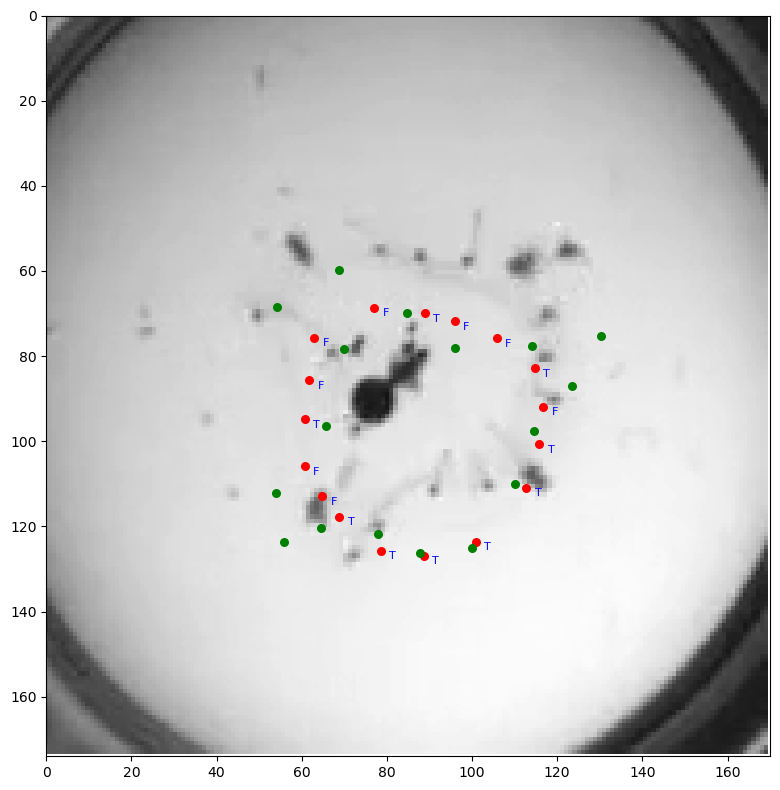

In [140]:
gt_text_dict = {0: 'F', 1: 'T', -1: 'nan'}
animation_path = '/home/mingxiao/Desktop/animation/gt_labels_thres_6.mp4'
animate_classification_results(cont_pred_pts_copy[1:], cont_gt_pts_copy[1:], unmasked_gt_labels,
                               bg_video=vid,
                               output_path=animation_path, 
                               bg_video_start_idx=1600,
                               text_dict=gt_text_dict)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/svm_grid_search_1_bg_1.mp4
Animation saved to /home/mingxiao/Desktop/animation/svm_grid_search_1_bg_1.mp4


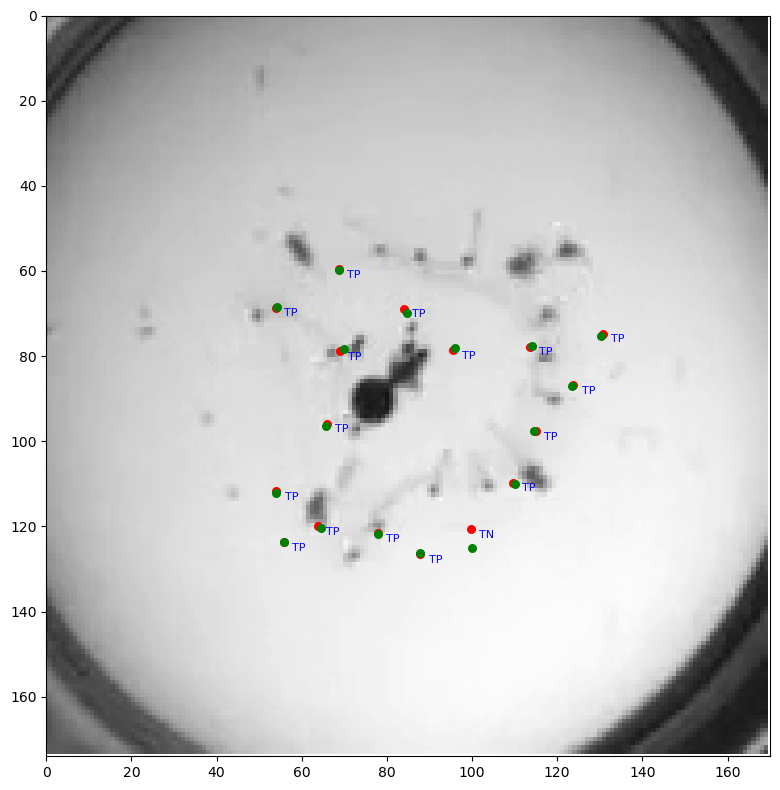

In [107]:
animation_path = '/home/mingxiao/Desktop/animation/svm_grid_search_1_bg_1.mp4'
animate_classification_results(cont_pred_pts_score[1:], cont_gt_pts[1:], unmasked_labels, 
                               bg_video=vid,
                               output_path=animation_path, 
                               bg_video_start_idx=1200)

### test on a different video clip

In [151]:
model_save_path = 'point_classifier_model.joblib'
svm_clf = joblib.load(model_save_path)
scaler_save_path = 'point_classifier_scaler.joblib'
scaler = joblib.load(scaler_save_path)

In [153]:
test_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_1m_w_scores.slp'
test_dataset = sleap.load_file(test_dataset_path)
print(test_dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)


In [154]:
test_pts = get_all_untracked_points(test_dataset, use_labeled_only=False, load_pred_score=True)
print(test_pts.shape)

all_untracked_points shape: (9000, 17, 3)


9000it [00:21, 410.16it/s]


First non missing frame idx: 0
Missing point count: 0
reorder_idx.shape: (17,)
(9000, 17, 3)


In [156]:
test_features, test_nan_mask = get_prediction_dataset(test_pts, return_nan_mask=True)
print(test_features.shape, test_nan_mask.shape)

(152983, 4) (8999, 17)


In [157]:
X_test_scaled = scaler.transform(test_features)
y_test = svm_clf.predict(X_test_scaled)
print(y_test.shape)

(152983,)


In [159]:
unmasked_y_test = unmask_labels(y_test, test_nan_mask)
print(unmasked_y_test.shape)

(8999, 17)


In [161]:
test_vid_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/animal_1_1h_1min.mp4'
test_vid = video_loader(test_vid_path)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/svm_test_animation.mp4
Animation saved to /home/mingxiao/Desktop/animation/svm_test_animation.mp4


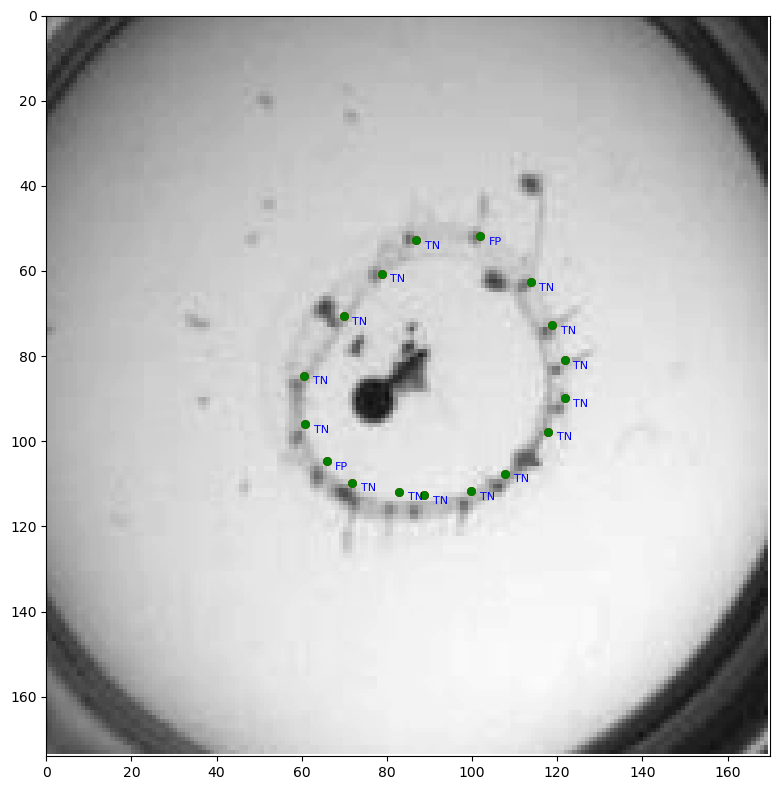

In [163]:
test_anim_path = '/home/mingxiao/Desktop/animation/svm_test_animation.mp4'
animate_classification_results(test_pts[1:], None, unmasked_y_test, 
                               bg_video=test_vid,
                               output_path=test_anim_path,
                               bg_video_start_idx=0)

# Assign point ID to the rest + Interpolation

For each point, find its nearest neighbor from the previous frame. -> should we use more sophisticated methods than that? 

Also test this method out on the ground truths :)

Need to look at the ground truth distribution of how much displacement there can be between two individual frames. 

## examine distribution of point displacements from the ground truth

In [141]:
gt_pts.shape

(4149, 17, 2)

(70504,)
min: 0.0, max: 102.5324938052164, mean: 5.0311269951948905, std: 8.271328944607596


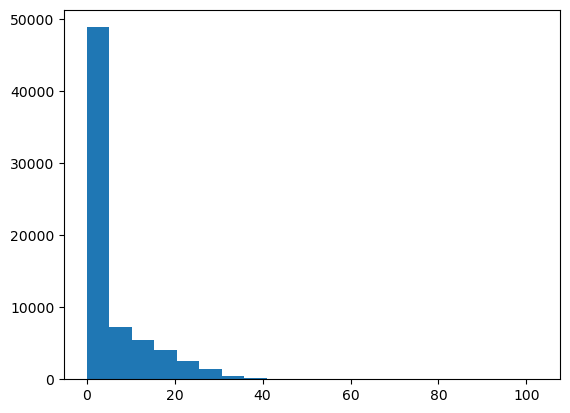

32.617267124913305


In [148]:
gt_pt_displacements = np.linalg.norm(gt_pts[1:] - gt_pts[:-1], axis=2)
gt_pt_displacements = gt_pt_displacements[~np.isnan(gt_pt_displacements)]
print(gt_pt_displacements.shape)
flat_displacements = gt_pt_displacements.flatten()
print(f'min: {flat_displacements.min()}, max: {flat_displacements.max()}, mean: {flat_displacements.mean()}, std: {flat_displacements.std()}')
plt.hist(flat_displacements, bins=20)
plt.show()
print(np.percentile(flat_displacements, 99))

In [ ]:
def assign_id(pts):
    """
    Assign point ID based on nearest neighbor from the previous frame by reordering the points. 
    Assume all points are correctly predicted on the first frame and mispredicted points are removed (represented as (0, 0)).
    Missing points are also represented as (0, 0).
    
    Input:
        pts: (frame_cnt, pt_cnt, 2)
    Output:
        id_pts: (frame_cnt, pt_cnt, 2)
    """
    # assume all points are correctly predicted on the first frame
    assert pts.ndim == 3, f'points should be 3D, but got {pts.ndim}D'
    if pts.shape[2] == 3:
        pts = pts[:, :, :2]
    pts[np.isnan(pts)] = 0
    first_frame_polygon_order = poly_4(pts[0])
    pts = pts[:, first_frame_polygon_order]
    id_pts = np.zeros_like(pts)
    frame_cnt, pt_cnt = pts.shape[:2]
    
    for frame_idx in range(1, frame_cnt):
        prev_pts = pts[frame_idx - 1]
        curr_pts = pts[frame_idx]
        id_indices = np.full(pt_cnt, -1)
        for pt_idx in range(pt_cnt):
            if curr_pts[pt_idx].sum() == 0:
                continue
            # find the nearest neighbor in the previous frame
            nn_idx = np.argmin(np.linalg.norm(prev_pts[id_indices] - curr_pts[pt_idx], axis=1))
            id_indices[pt_idx] = nn_idx
        id_pts[frame_idx,] = pts[frame_idx][id_indices]
    return id_pts
                

# Interpolation

In [164]:
arr = np.arange(24).reshape(4, 3, 2)
arr

array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5]],

       [[ 6,  7],
        [ 8,  9],
        [10, 11]],

       [[12, 13],
        [14, 15],
        [16, 17]],

       [[18, 19],
        [20, 21],
        [22, 23]]])

In [ ]:
def flow_interpolate(pts, curr_frame_idx):
    assert pts.ndim == 3, f'points should be 3D, but got {pts.ndim}D'
    if pts.shape[2] == 3:
        pts = pts[:, :, :2]
        
    if curr_frame_idx < 2: # flow interpolation needs at least 3 frames 
        pts[curr_frame_idx] = polar_interpolate(pts[curr_frame_idx])
        return pts
    
    past_frames = pts[:curr_frame_idx]
    past_non_missing_mask = ~(past_frames == 0).all(axis=2)
    

# Polygon-based correction